# Vision Transformer

This notebook looks to replicate the Vision Transformer model architecture for image processing as discussed in the paper
["AN IMAGE IS WORTH 16X16 WORDS:
TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE"](https://arxiv.org/pdf/2010.11929)

The Transformer model has been extremely beneficial in processing of text data, which eventually led to the formation of groundbreaking Large Language Models (LLMs), like Chatgpt.

However tasks related to image processing and computer vision still rely on traditional CNNs. This work looks to demonstrate that the concept of "Transformers" is not only limited to natural language processing tasks, but can be extended to image processing tasks with modifications such as multihead attention.
This reduces dependency on CNNs and allows us to accomplish our goals with fewer resources.

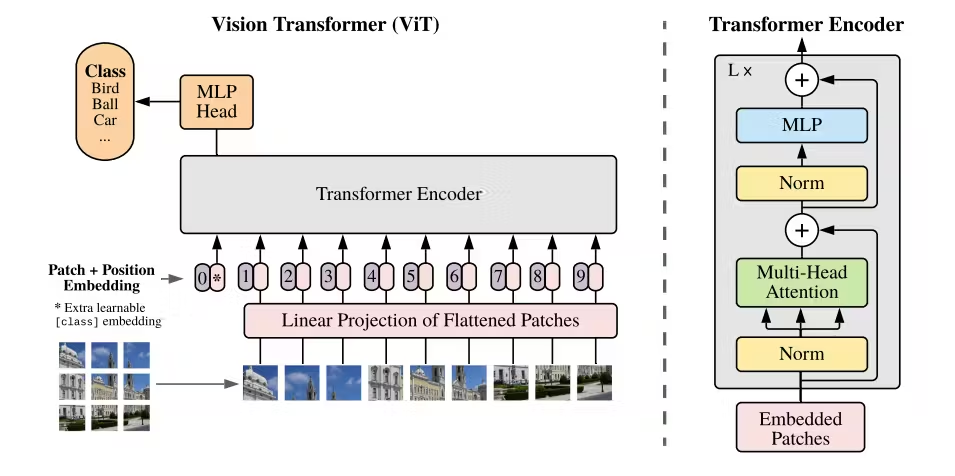

# Importing libraries

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.optim import Adam
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import numpy as np


# Patch embeddings

In [2]:
class PatchEmbedding(nn.Module):
  def __init__(self,d_model, img_size, patch_size, n_channels):
    super().__init__() #for inheritance to parent class nn.Module


    self.d_model=d_model # order of vectors
    self.img_size=img_size #size of the image
    self.patch_size=patch_size #size of each patch
    self.n_channels=n_channels #number of channels in the image

    #creating patches from the image

    self.linear_project=nn.Conv2d(self.n_channels, self.d_model, kernel_size=self.patch_size, stride=self.patch_size)

      # B: Batch Size
  # C: Image Channels
  # H: Image Height
  # W: Image Width
  # P_col: Patch Column
  # P_row: Patch Row


  #function to process the input image using a neural network
  def forward(self,x):
    x=self.linear_project(x)
    x=x.flatten(2)
    x=x.transpose(1,2)
    return x


# CLS token and Positional embedding



In [3]:
class PositionalEncoding(nn.Module):
  def __init__(self,d_model,max_seq_length):
    super().__init__()

    self.cls_token=nn.Parameter(torch.randn(1,1,d_model)) #classification token
    #self.pos_embedding=nn.Parameter(torch.randn(1,max_seq_length,d_model))


    #positional encoding
    pe=torch.zeros(max_seq_length,d_model)
    #  pe is initialized as a tensor of zeros with the line pe = torch.zeros(max_seq_length, d_model).
    #The subsequent loops then populate this tensor with the positional encoding values based on sine and cosine functions.

    for pos in range(max_seq_length):
      for i in range(d_model):
        if i%2==0:
          pe[pos,i]=np.sin(pos/(10000** (i/d_model)))
        else:
          pe[pos,i]=np.cos(pos/(10000** (i-1/d_model)))
    self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self,x):
      #expand to class token for each image in batch
      tokens_batch = self.cls_token.expand(x.size()[0], -1, -1)

       # Adding class tokens to the beginning of each embedding
      x = torch.cat((tokens_batch,x), dim=1)

       # Add positional encoding to embeddings
      x = x + self.pe

      return x



In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super().__init__()

        # Classification token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # Positional encoding (+1 for CLS token)
        pe = torch.zeros(max_seq_length + 1, d_model)

        for pos in range(max_seq_length + 1):
            for i in range(0, d_model, 2):
                pe[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
                if i + 1 < d_model:
                    pe[pos, i + 1] = np.cos(pos / (10000 ** (i / d_model)))

        # Not trainable (standard sinusoidal PE)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        """
        x shape: (batch_size, num_patches, d_model)
        """

        B = x.size(0)

        # Expand CLS token for batch
        cls_tokens = self.cls_token.expand(B, -1, -1)

        # Concatenate CLS token
        x = torch.cat((cls_tokens, x), dim=1)

        # Add positional encoding
        x = x + self.pe[:, :x.size(1), :]

        return x


# **Making the Attention Head**

ViTs use attention as a means of communication that allows them to focus on the important aspects of the image.

In [5]:
class AttentionHead(nn.Module):
  def __init__(self, d_model, head_size):
    super().__init__()
    self.head_size=head_size

    self.query=nn.Linear(d_model, head_size)
    self.key=nn.Linear(d_model, head_size)
    self.value=nn.Linear(d_model, head_size)


  def forward(self,x):

      Q=self.query(x)
      K=self.key(x)
      V=self.value(x)


      #dot product of the attention
      attention=Q@K.transpose(-2,-1)

      attention=attention/(self.head_size**0.5)

      attention=torch.softmax(attention, dim=1)

      attention=attention@V
      return attention

# **Multihead attention**

The same principle of attention will be applied multiple times, in parallel and will be combined later.

Note: For an activation function we are using GELU(Gaussian Error linear Unit) instead of RELU because it does not have the limitation of becoming non differentiable at 0

In [6]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, n_heads):
    super().__init__()
    self.head_size=int(d_model/n_heads)
    self.W_o=nn.Linear(d_model, d_model)

    self.heads = nn.ModuleList([AttentionHead(d_model, self.head_size) for _ in range(n_heads)])
  def forward(self,x):
      #adding the attention heads to get the final attention
          out = torch.cat([head(x) for head in self.heads], dim=-1)

          out = self.W_o(out)

          return out

# **Transformer encoder**

r_mlp=4
ratio of mlp: decides how much the FFN expands or contracts wrt model dimension


Formula:
Linear=(d_model, dff)-> GELU->Linear(dff,d_model)

dff=r_mlp*d_model

Helps capture non linear relationships better; The intermediate space becomes larger for the model to operate

In [7]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self, d_model, r_mlp=4, n_heads=8):
    super().__init__()
    self.d_model=d_model
    self.n_heads=n_heads


    #Layer normalization across all batches
    self.ln1=nn.LayerNorm(d_model)

    #multihead attentiom

    self.mha=MultiHeadAttention(d_model, n_heads)

    #Layer normalization across all batches 2.0
    self.ln2=nn.LayerNorm(d_model)

    #mlp

    self.mlp=nn.Sequential(nn.Linear(d_model,d_model*r_mlp),nn.GELU(),nn.Linear(d_model*r_mlp, d_model))

  def forward(self,x):
      #residual connections-because of vanishing gradient problem

       out=x+self.mha(self.ln1(x))

       out=out+self.mlp(self.ln2(out))

       return out



# Vision Transformer

When creating our ViT class we have to ensure that all the patches of images are of same size and the d_model is divisible by the number of attention heads

number of patches can be found by dividing the product of the height and width of the input image by the product of the height and width of the patch size.

Max sequence length=No.of patches+1


In [8]:
class VisionTransformer(nn.Module):
  def __init__(self, d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers):
    super().__init__()
    assert img_size[0] % patch_size[0] == 0 and img_size[1] % patch_size[1] == 0, "img_size dimensions must be divisible by patch_size dimensions"
    assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

    self.d_model=d_model
    self.n_classes=n_classes
    self.img_size=img_size
    self.patch_size=patch_size
    self.n_channels=n_channels
    self.n_heads=n_heads


    #no of patches
    self.n_patches=(self.img_size[0] * self.img_size[1] ) // (self.patch_size[0]*self.patch_size[1])
    #No of patches
    self. max_seq_length=self.n_patches+1

    #defining: patch embeddings, positional encodings and transformer architecture for this particular class

    #self.patch_embedding= PatchEmbedding(d_model, img_size, patch_size, n_channels)
    #self.positional_encoding= PositionalEncoding(d_model, max_seq_length)
    #self.transformer_encoder= TransformerEncoder(d_model, n_heads)


    self.patch_embedding = PatchEmbedding(self.d_model, self.img_size, self.patch_size, self.n_channels)
    self.positional_encoding = PositionalEncoding( self.d_model, self.max_seq_length)
    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock( self.d_model, self.n_heads) for _ in range(n_layers)])



  #MLP layer

    self.classifier = nn.Sequential(
        nn.Linear(self.d_model, self.n_classes),
        nn.Softmax(dim=-1)
    )

  def forward(self, images):
    x = self.patch_embedding(images)

    x = self.positional_encoding(x)

    x = self.transformer_encoder(x)

    x = self.classifier(x[:,0])


    return x


Summary of what we have done so far:

step 1: The input images are passed through the patch embeddings first to split them into patches

step2: from the patches the linear embeddings are obtained

step3: The linear embeddings are passed through the positional encoding layer and the classification token (cls token) is added through the two encoder modules

step 4: The cls tokens go through the MLP to classify the images (classes of the image)

# **Training parameters**

In [9]:
d_model = 32
n_classes = 10
img_size = (32,32)
patch_size = (16,16)
n_channels = 1
n_heads = 4
n_layers = 3
batch_size = 128
epochs = 20
alpha = 0.0001

# **Loading the dataset


**

In [10]:
transform=T.Compose([T.Resize(img_size), T.ToTensor()])


train_set=MNIST(root='./datasets', train=True, download=True, transform=transform)
test_set=MNIST(root='./datasets', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_set, shuffle=False, batch_size=batch_size)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


# **Training**

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")

transformer = VisionTransformer(d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers).to(device)

optimizer = Adam(transformer.parameters(), lr=alpha)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):

  training_loss = 0.0
  for i, data in enumerate(train_loader, 0):
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = transformer(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    training_loss += loss.item()

  print(f'Epoch {epoch + 1}/{epochs} loss: {training_loss  / len(train_loader) :.3f}')

Using device:  cuda (Tesla T4)
Epoch 1/20 loss: 1.937
Epoch 2/20 loss: 1.652
Epoch 3/20 loss: 1.623
Epoch 4/20 loss: 1.609
Epoch 5/20 loss: 1.601
Epoch 6/20 loss: 1.595
Epoch 7/20 loss: 1.591
Epoch 8/20 loss: 1.588
Epoch 9/20 loss: 1.585
Epoch 10/20 loss: 1.569
Epoch 11/20 loss: 1.513
Epoch 12/20 loss: 1.506
Epoch 13/20 loss: 1.501
Epoch 14/20 loss: 1.499
Epoch 15/20 loss: 1.496
Epoch 16/20 loss: 1.494
Epoch 17/20 loss: 1.492
Epoch 18/20 loss: 1.491
Epoch 19/20 loss: 1.489
Epoch 20/20 loss: 1.489


In [12]:
correct = 0
total = 0

with torch.no_grad():
  for data in test_loader:
    images, labels = data
    images, labels = images.to(device), labels.to(device)

    outputs = transformer(images)

    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
  print(f'\nModel Accuracy: {100 * correct // total} %')


Model Accuracy: 96 %


# Macro precision, recall and avg

Note:
In a multi-class classification setting such as MNIST, precision and recall are first defined per class.
For a given class
𝑐
c, precision and recall are defined as:
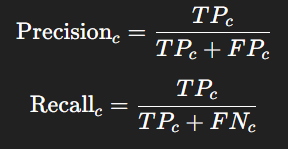


where
𝑇
𝑃
𝑐
TP
c
	​

,
𝐹
𝑃
𝑐
FP
c
	​

, and
𝐹
𝑁
𝑐
FN
c
	​

 denote the true positives, false positives, and false negatives for class
𝑐
c, respectively.

Since MNIST contains multiple classes (digits 0–9), a single scalar metric is obtained by macro-averaging, which computes the metric independently for each class and then takes the unweighted mean across all classes:

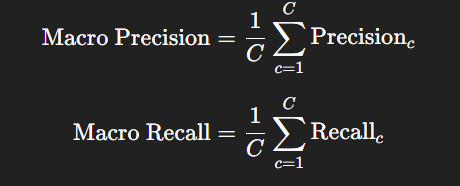

where
𝐶
C is the total number of classes.

The macro-averaged F1-score is then computed as:

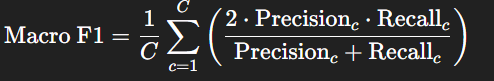

Macro-averaging treats all classes equally, regardless of class frequency, and therefore provides a balanced and unbiased evaluation of model performance across all digit categories. This is particularly appropriate for MNIST, which is a class-balanced dataset.

In [13]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
transformer.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = transformer(images)   # 👈 your existing model
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [14]:
transformer.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = transformer(images)   # 👈 your existing model
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [15]:
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Accuracy:        {sum(p==l for p,l in zip(all_preds, all_labels))/len(all_labels):.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1-score:  {f1:.4f}")


Accuracy:        0.9680
Macro Precision: 0.9678
Macro Recall:    0.9678
Macro F1-score:  0.9677


# Training vs Validation loss

In [17]:
train_losses=[]
val_losses=[]

for epoch in range(epochs):

    # ---- TRAIN ----
    transformer.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = transformer(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- VALIDATION ----
    transformer.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = transformer(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")


Epoch [1/20] Train Loss: 1.4869 | Val Loss: 1.4917
Epoch [2/20] Train Loss: 1.4857 | Val Loss: 1.4919
Epoch [3/20] Train Loss: 1.4848 | Val Loss: 1.4912
Epoch [4/20] Train Loss: 1.4840 | Val Loss: 1.4897
Epoch [5/20] Train Loss: 1.4829 | Val Loss: 1.4904
Epoch [6/20] Train Loss: 1.4831 | Val Loss: 1.4904
Epoch [7/20] Train Loss: 1.4816 | Val Loss: 1.4902
Epoch [8/20] Train Loss: 1.4813 | Val Loss: 1.4879
Epoch [9/20] Train Loss: 1.4808 | Val Loss: 1.4885
Epoch [10/20] Train Loss: 1.4800 | Val Loss: 1.4884
Epoch [11/20] Train Loss: 1.4803 | Val Loss: 1.4881
Epoch [12/20] Train Loss: 1.4795 | Val Loss: 1.4904
Epoch [13/20] Train Loss: 1.4789 | Val Loss: 1.4861
Epoch [14/20] Train Loss: 1.4780 | Val Loss: 1.4887
Epoch [15/20] Train Loss: 1.4781 | Val Loss: 1.4872
Epoch [16/20] Train Loss: 1.4771 | Val Loss: 1.4893
Epoch [17/20] Train Loss: 1.4780 | Val Loss: 1.4874
Epoch [18/20] Train Loss: 1.4769 | Val Loss: 1.4876
Epoch [19/20] Train Loss: 1.4762 | Val Loss: 1.4869
Epoch [20/20] Train L

The training loss exhibits a smooth and monotonic decrease across epochs, indicating stable and well-conditioned optimization.

 The validation loss remains closely aligned with the training loss, with minor fluctuations that are expected due to batch-level variance. The absence of divergence between training and validation loss suggests that the model does not suffer from overfitting. Although the absolute cross-entropy loss values decrease gradually, this behavior is typical for transformer-based architectures trained with a low learning rate, where predictions become increasingly correct without excessive overconfidence.

 The observed loss trends are consistent with the achieved high classification accuracy and indicate robust generalization.